# ESM2 Acetylation Prediction (Clean Pipeline)

Binary protein-level classifier: **acetylated vs non-acetylated**.

## What this notebook does
- Loads UniProt table and defines binary labels using the `Post-translational modification` column.
- Loads precomputed ESM2 embeddings (max pool + attention pool, 1280-dim).
- Trains and compares Logistic Regression and MLP classifiers.
- Evaluates ROC-AUC, PR-AUC, F1, MCC, and confusion matrices.
- Generates PCA, t-SNE, and UMAP embedding visualisations.
- Saves plots, summary tables, and an HTML report to `results_acetylation_ESM2/`.


In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix,
    precision_score, recall_score, f1_score,
    matthews_corrcoef,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
PROJECT_DIR = Path.cwd()
candidate_data_dirs = [
    (PROJECT_DIR / ".." / ".." / "all_uniref").resolve(),
    (PROJECT_DIR / ".." / "all_uniref").resolve(),
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), candidate_data_dirs[0])
RESULTS_DIR = PROJECT_DIR / "results_acetylation_ESM2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

UNIPROT_FILE = DATA_DIR / "uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv"
EMBED_FILE   = Path("/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref") / "esm2_embedding_cache" / "pooled_embeddings.npz"

print(f"Project directory  : {PROJECT_DIR}")
print(f"Data directory     : {DATA_DIR}")
print(f"Results directory  : {RESULTS_DIR}")
print(f"UniProt file exists: {UNIPROT_FILE.exists()}")
print(f"Embedding file exists: {EMBED_FILE.exists()}")


Project directory  : /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation
Data directory     : /home/saishyam/Protein_dynamics/all_uniref
Results directory  : /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2
UniProt file exists: True
Embedding file exists: True


In [3]:
all_uniref = pd.read_csv(UNIPROT_FILE, sep="\t")


def build_clean_label_sets(df: pd.DataFrame):
    """Split into acetylated vs non-acetylated using the PTM free-text column."""
    ptm  = df["Post-translational modification"].fillna("")
    mask = ptm.str.contains(r"acetyl", case=False, regex=True)

    pos = df[mask].copy()
    neg = df[~mask].copy()

    cols       = ["Entry", "Protein names", "Sequence"]
    rename_map = {
        "Entry":         "protein_id",
        "Protein names": "protein_name",
        "Sequence":      "sequence",
    }
    pos = pos.loc[:, cols].rename(columns=rename_map)
    neg = neg.loc[:, cols].rename(columns=rename_map)

    pos = pos.drop_duplicates(subset="protein_name", keep="first")
    neg = neg.drop_duplicates(subset="protein_name", keep="first")

    overlap = set(pos["protein_name"]) & set(neg["protein_name"])
    pos     = pos[~pos["protein_name"].isin(overlap)]
    neg     = neg[~neg["protein_name"].isin(overlap)]

    pos = pos.reset_index(drop=True)
    neg = neg.reset_index(drop=True)

    assert pos["protein_name"].is_unique
    assert neg["protein_name"].is_unique
    assert set(pos["protein_name"]).isdisjoint(set(neg["protein_name"]))
    return pos, neg


acetyl_df, nacetyl_df = build_clean_label_sets(all_uniref)

class_counts = pd.DataFrame({
    "Class": ["Acetylated", "Not acetylated"],
    "Count": [len(acetyl_df), len(nacetyl_df)],
})
class_counts["Fraction"] = class_counts["Count"] / class_counts["Count"].sum()

print(f"Acetylated        : {len(acetyl_df):,}")
print(f"Not acetylated    : {len(nacetyl_df):,}")
print(f"Total             : {len(acetyl_df) + len(nacetyl_df):,}")
print(class_counts)


Acetylated        : 354
Not acetylated    : 18,105
Total             : 18,459
            Class  Count  Fraction
0      Acetylated    354  0.019178
1  Not acetylated  18105  0.980822


/tmp/ipykernel_3973986/2684106783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count",


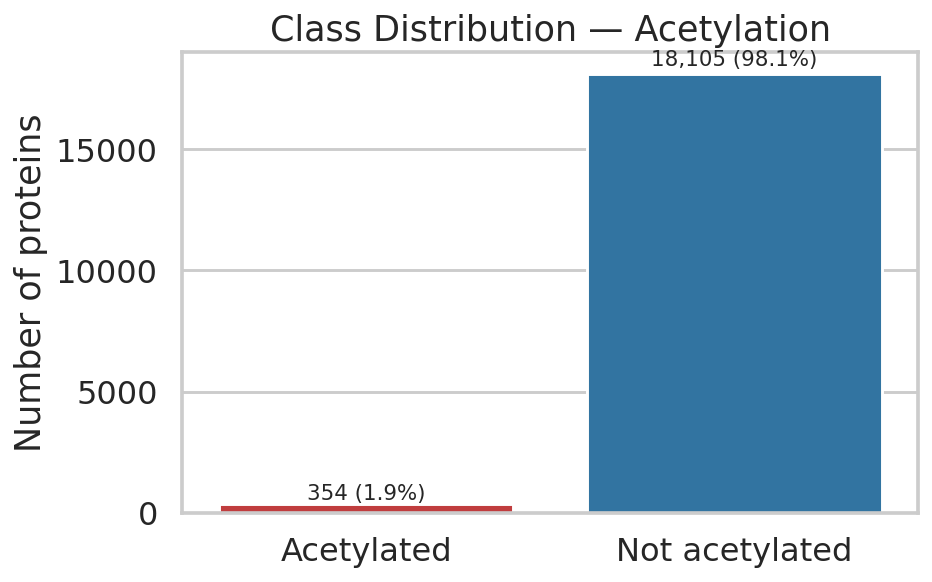

Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/class_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=class_counts, x="Class", y="Count",
            palette=["#d62728", "#1f77b4"], ax=ax)
ax.set_title("Class Distribution — Acetylation")
ax.set_xlabel("")
ax.set_ylabel("Number of proteins")
for i, row in class_counts.iterrows():
    ax.text(i, row["Count"] * 1.01,
            f"{row['Count']:,} ({row['Fraction']:.1%})",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
class_dist_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(class_dist_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {class_dist_path}")


In [5]:
cache     = np.load(EMBED_FILE, allow_pickle=True)
max_pool  = cache["max"].item()   # dict: protein_id -> ndarray
attn_pool = cache["attn"].item()  # dict: protein_id -> ndarray


def collect_embeddings(df: pd.DataFrame, pool_dict: dict, label: str) -> np.ndarray:
    vectors, missing = [], []
    for pid in df["protein_id"]:
        vec = pool_dict.get(pid)
        if vec is None:
            missing.append(pid)
        else:
            vectors.append(vec)
    if not vectors:
        raise ValueError(f"No embeddings found for: {label}")
    if missing:
        print(f"[{label}] Missing: {len(missing)}")
    return np.stack(vectors)


X_pos_max  = collect_embeddings(acetyl_df,  max_pool,  "acetylated|max")
X_neg_max  = collect_embeddings(nacetyl_df, max_pool,  "not_acetylated|max")
X_pos_attn = collect_embeddings(acetyl_df,  attn_pool, "acetylated|attn")
X_neg_attn = collect_embeddings(nacetyl_df, attn_pool, "not_acetylated|attn")

emb_dim = X_pos_attn.shape[1]
assert emb_dim == 1280, f"Expected 1280-dim, got {emb_dim}"
print(f"Max pool  shapes : {X_pos_max.shape}   {X_neg_max.shape}")
print(f"Attn pool shapes : {X_pos_attn.shape}   {X_neg_attn.shape}")
print(f"Embedding dim    : {emb_dim}")


Max pool  shapes : (354, 1280)   (18105, 1280)
Attn pool shapes : (354, 1280)   (18105, 1280)
Embedding dim    : 1280


In [6]:
def make_split(pos: np.ndarray, neg: np.ndarray):
    X = np.vstack([pos, neg]).astype(np.float32)
    y = np.array([1] * len(pos) + [0] * len(neg), dtype=np.int64)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test  = scaler.transform(X_test).astype(np.float32)
    return X_train, X_test, y_train, y_test


split_data = {
    "max":  make_split(X_pos_max,  X_neg_max),
    "attn": make_split(X_pos_attn, X_neg_attn),
}


def evaluate_binary(y_true: np.ndarray, y_prob: np.ndarray,
                     threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "roc_auc":   roc_auc_score(y_true, y_prob),
        "pr_auc":    average_precision_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "mcc":       matthews_corrcoef(y_true, y_pred),
        "tn": int(tn), "fp": int(fp),
        "fn": int(fn), "tp": int(tp),
    }


results    = []
curve_data = {}

t0 = time.perf_counter()
for pooling_name, (Xtr, Xte, ytr, yte) in split_data.items():
    clf = LogisticRegression(
        max_iter=5000, class_weight="balanced", n_jobs=-1, random_state=SEED
    )
    clf.fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]

    metrics = evaluate_binary(yte, prob)
    metrics.update({
        "model": "logistic_regression", "pooling": pooling_name,
        "n_test": int(len(yte)), "positive_rate_test": float(yte.mean()),
    })
    results.append(metrics)

    fpr, tpr, _ = roc_curve(yte, prob)
    prec, rec, _ = precision_recall_curve(yte, prob)
    curve_data[("logistic_regression", pooling_name)] = {
        "y_true": yte, "y_prob": prob,
        "fpr": fpr, "tpr": tpr,
        "precision": prec, "recall": rec,
    }
    print(f"LR  | {pooling_name:4s} → ROC-AUC={metrics['roc_auc']:.4f}  "
          f"PR-AUC={metrics['pr_auc']:.4f}  F1={metrics['f1']:.4f}  MCC={metrics['mcc']:.4f}")

print(f"\nLogistic Regression complete in {time.perf_counter()-t0:.1f}s")


/home/saishyam/esm2_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR  | max  → ROC-AUC=0.6792  PR-AUC=0.0925  F1=0.1811  MCC=0.1749


/home/saishyam/esm2_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR  | attn → ROC-AUC=0.7644  PR-AUC=0.1146  F1=0.1948  MCC=0.1956

Logistic Regression complete in 23.8s


In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_mlp(Xtr, ytr, Xte, yte, epochs=30, batch_size=64, lr=1e-3):
    Xtr_t = torch.from_numpy(Xtr)
    ytr_t = torch.from_numpy(ytr.astype(np.float32))
    Xte_t = torch.from_numpy(Xte)

    train_loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True
    )

    pos = ytr.sum()
    neg = len(ytr) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)],
                              dtype=torch.float32, device=device)

    model     = MLP(Xtr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    model.train()
    for _ in range(epochs):
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        losses.append(running / len(train_loader))

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t.to(device))).cpu().numpy()
    return probs, losses


training_loss = {}
t0 = time.perf_counter()
for pooling_name, (Xtr, Xte, ytr, yte) in split_data.items():
    probs, losses = train_mlp(Xtr, ytr, Xte, yte)
    metrics = evaluate_binary(yte, probs)
    metrics.update({
        "model": "mlp", "pooling": pooling_name,
        "n_test": int(len(yte)), "positive_rate_test": float(yte.mean()),
    })
    results.append(metrics)

    fpr, tpr, _ = roc_curve(yte, probs)
    prec, rec, _ = precision_recall_curve(yte, probs)
    curve_data[("mlp", pooling_name)] = {
        "y_true": yte, "y_prob": probs,
        "fpr": fpr, "tpr": tpr,
        "precision": prec, "recall": rec,
    }
    training_loss[pooling_name] = losses
    print(f"MLP | {pooling_name:4s} → ROC-AUC={metrics['roc_auc']:.4f}  "
          f"PR-AUC={metrics['pr_auc']:.4f}  F1={metrics['f1']:.4f}  MCC={metrics['mcc']:.4f}")

print(f"\nMLP training complete in {time.perf_counter()-t0:.1f}s")


MLP | max  → ROC-AUC=0.7644  PR-AUC=0.2130  F1=0.1993  MCC=0.2040
MLP | attn → ROC-AUC=0.8146  PR-AUC=0.2273  F1=0.2192  MCC=0.2127

MLP training complete in 20.8s


In [8]:
results_df = pd.DataFrame(results)
results_df = results_df[[
    "model", "pooling", "roc_auc", "pr_auc",
    "precision", "recall", "f1", "mcc",
    "tp", "fp", "tn", "fn",
    "n_test", "positive_rate_test",
]]
results_df = results_df.sort_values(["roc_auc", "pr_auc"],
                                     ascending=False).reset_index(drop=True)

csv_path = RESULTS_DIR / "summary_metrics.csv"
md_path  = RESULTS_DIR / "summary_metrics.md"
results_df.to_csv(csv_path, index=False)
header    = "| " + " | ".join(results_df.columns) + " |"
separator = "|" + "|".join(["---"] * len(results_df.columns)) + "|"
rows      = ["| " + " | ".join(map(str, row)) + " |"
             for row in results_df.to_numpy()]
md_path.write_text("\n".join([header, separator] + rows))

display(results_df.style.format({
    "roc_auc":   "{:.4f}", "pr_auc":    "{:.4f}",
    "precision": "{:.4f}", "recall":    "{:.4f}",
    "f1":        "{:.4f}", "mcc":       "{:.4f}",
    "positive_rate_test": "{:.4f}",
}))
print(f"Saved: {csv_path}")
print(f"Saved: {md_path}")


,model,pooling,roc_auc,pr_auc,precision,recall,f1,mcc,tp,fp,tn,fn,n_test,positive_rate_test
0,mlp,attn,0.8146,0.2273,0.1622,0.3380,0.2192,0.2127,24,124,3497,47,3692,0.0192
1,logistic_regression,attn,0.7644,0.1146,0.1327,0.3662,0.1948,0.1956,26,170,3451,45,3692,0.0192
2,mlp,max,0.7644,0.2130,0.1333,0.3944,0.1993,0.2040,28,182,3439,43,3692,0.0192
3,logistic_regression,max,0.6792,0.0925,0.1279,0.3099,0.1811,0.1749,22,150,3471,49,3692,0.0192


Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/summary_metrics.csv
Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/summary_metrics.md


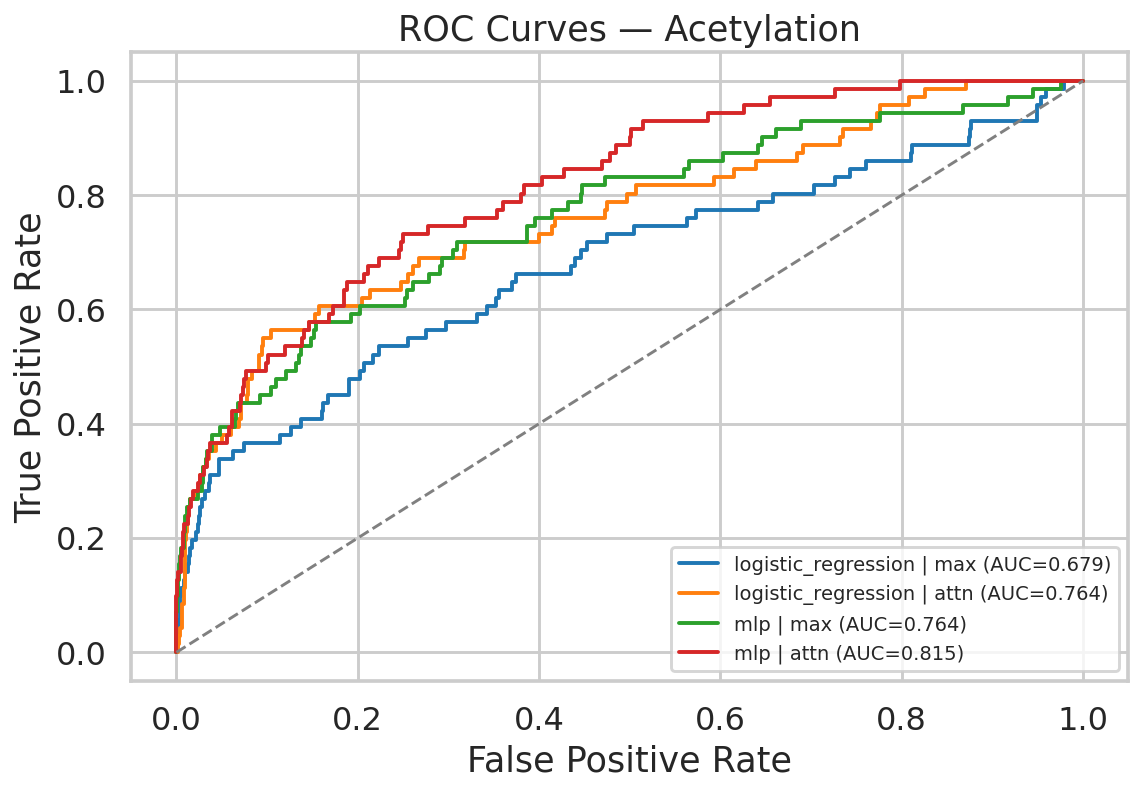

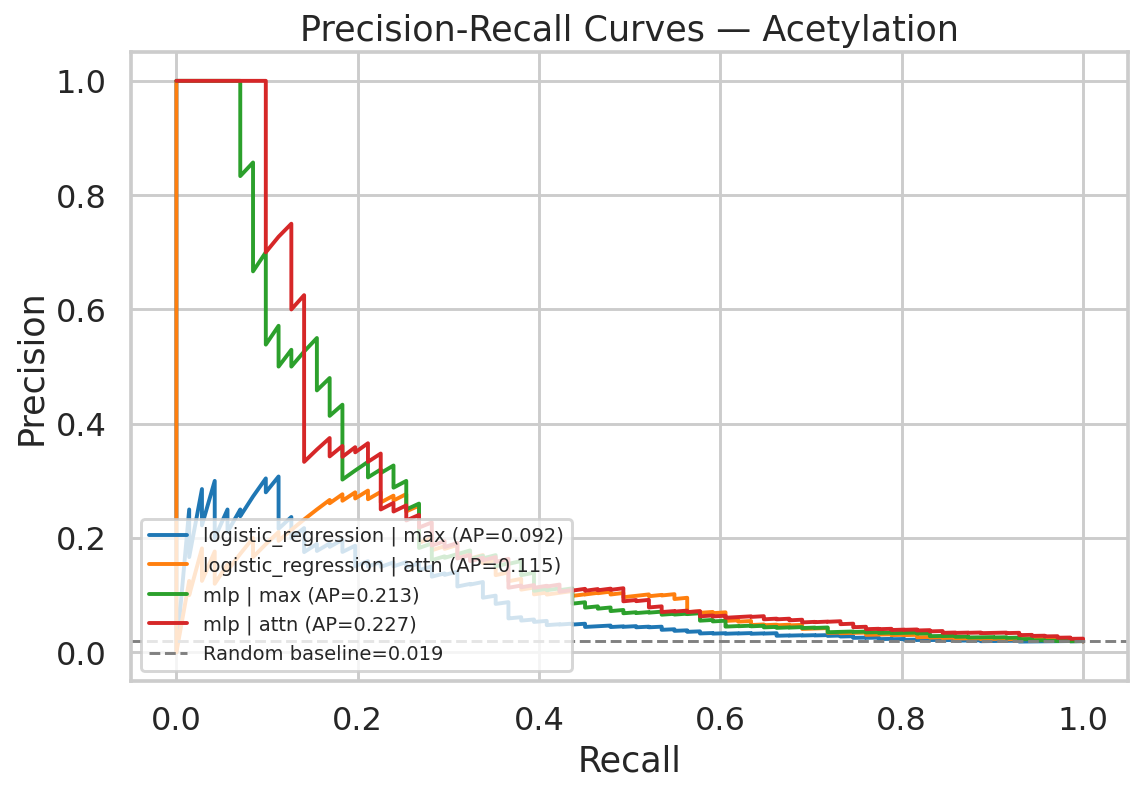

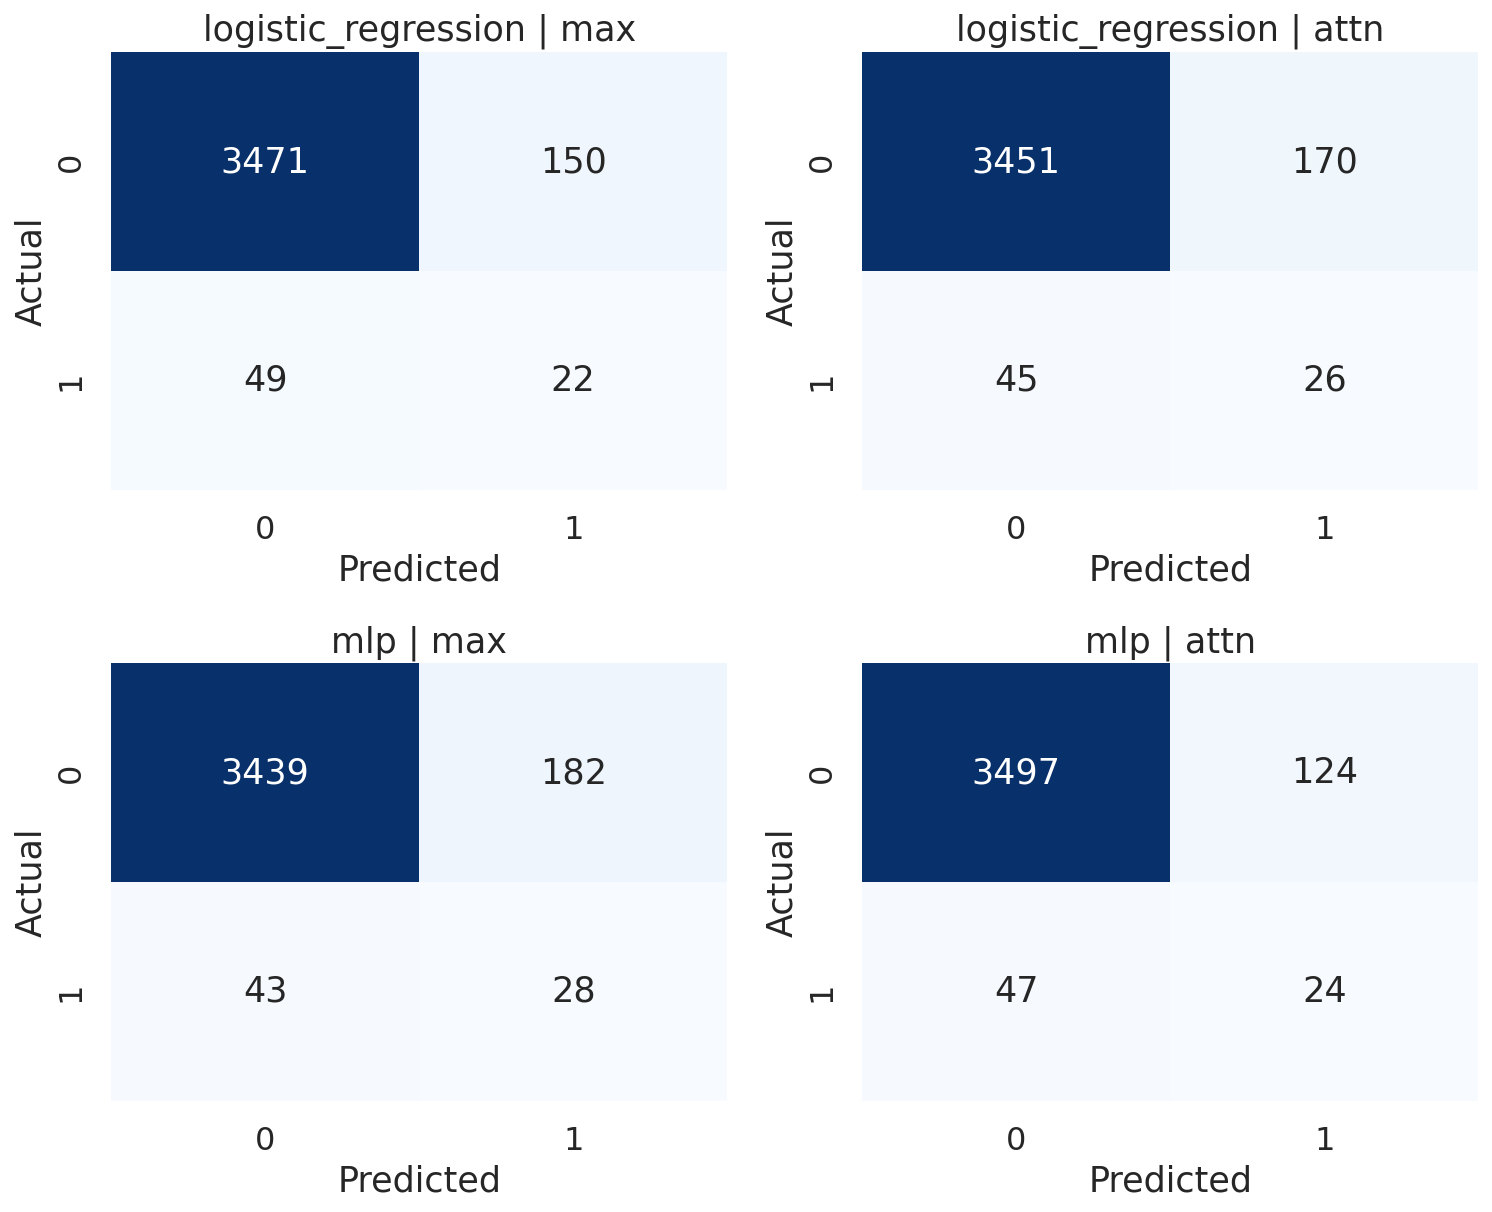

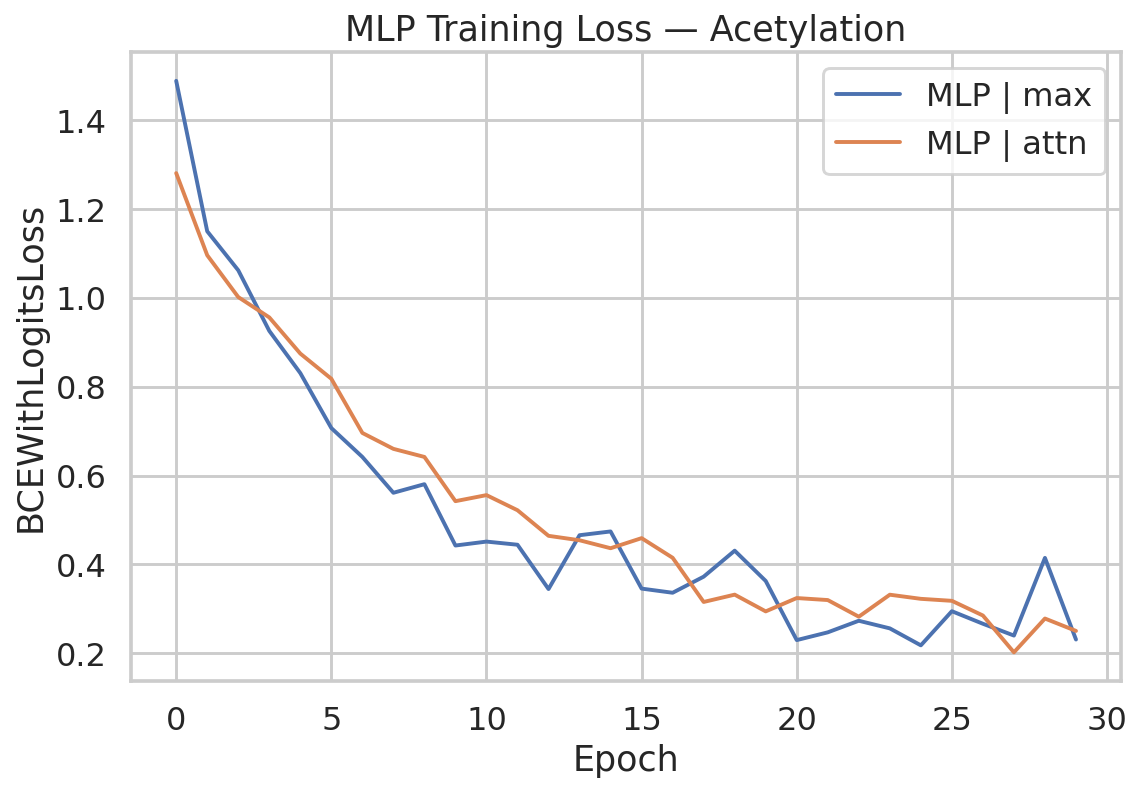

Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/roc_curves.png
Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/pr_curves.png
Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/confusion_matrices.png
Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/mlp_training_loss.png


In [9]:
palette = {
    ("logistic_regression", "max"):  "#1f77b4",
    ("logistic_regression", "attn"): "#ff7f0e",
    ("mlp", "max"):                  "#2ca02c",
    ("mlp", "attn"):                 "#d62728",
}

# ---- ROC curves ----
fig, ax = plt.subplots(figsize=(8.5, 6))
for key, data in curve_data.items():
    model, pooling = key
    label = (f"{model} | {pooling} "
             f"(AUC={roc_auc_score(data['y_true'], data['y_prob']):.3f})")
    ax.plot(data["fpr"], data["tpr"], label=label,
            color=palette[key], linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5)
ax.set_title("ROC Curves — Acetylation")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
roc_path = RESULTS_DIR / "roc_curves.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- PR curves ----
fig, ax = plt.subplots(figsize=(8.5, 6))
baseline = list(curve_data.values())[0]["y_true"].mean()
for key, data in curve_data.items():
    model, pooling = key
    label = (f"{model} | {pooling} "
             f"(AP={average_precision_score(data['y_true'], data['y_prob']):.3f})")
    ax.plot(data["recall"], data["precision"], label=label,
            color=palette[key], linewidth=2)
ax.axhline(baseline, linestyle="--", color="gray", linewidth=1.5,
           label=f"Random baseline={baseline:.3f}")
ax.set_title("Precision-Recall Curves — Acetylation")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=10, loc="lower left")
plt.tight_layout()
pr_path = RESULTS_DIR / "pr_curves.png"
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- Confusion matrices ----
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, key in zip(axes.ravel(), curve_data.keys()):
    model, pooling = key
    y_true = curve_data[key]["y_true"]
    y_pred = (curve_data[key]["y_prob"] >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{model} | {pooling}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
cm_path = RESULTS_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- MLP training loss ----
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(training_loss["max"],  label="MLP | max",  linewidth=2)
ax.plot(training_loss["attn"], label="MLP | attn", linewidth=2)
ax.set_title("MLP Training Loss — Acetylation")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCEWithLogitsLoss")
ax.legend()
plt.tight_layout()
loss_path = RESULTS_DIR / "mlp_training_loss.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {roc_path}")
print(f"Saved: {pr_path}")
print(f"Saved: {cm_path}")
print(f"Saved: {loss_path}")


Visualising 5,000 points (95 pos, 4905 neg)
t-SNE complete in 28.8s


/home/saishyam/esm2_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete in 24.8s


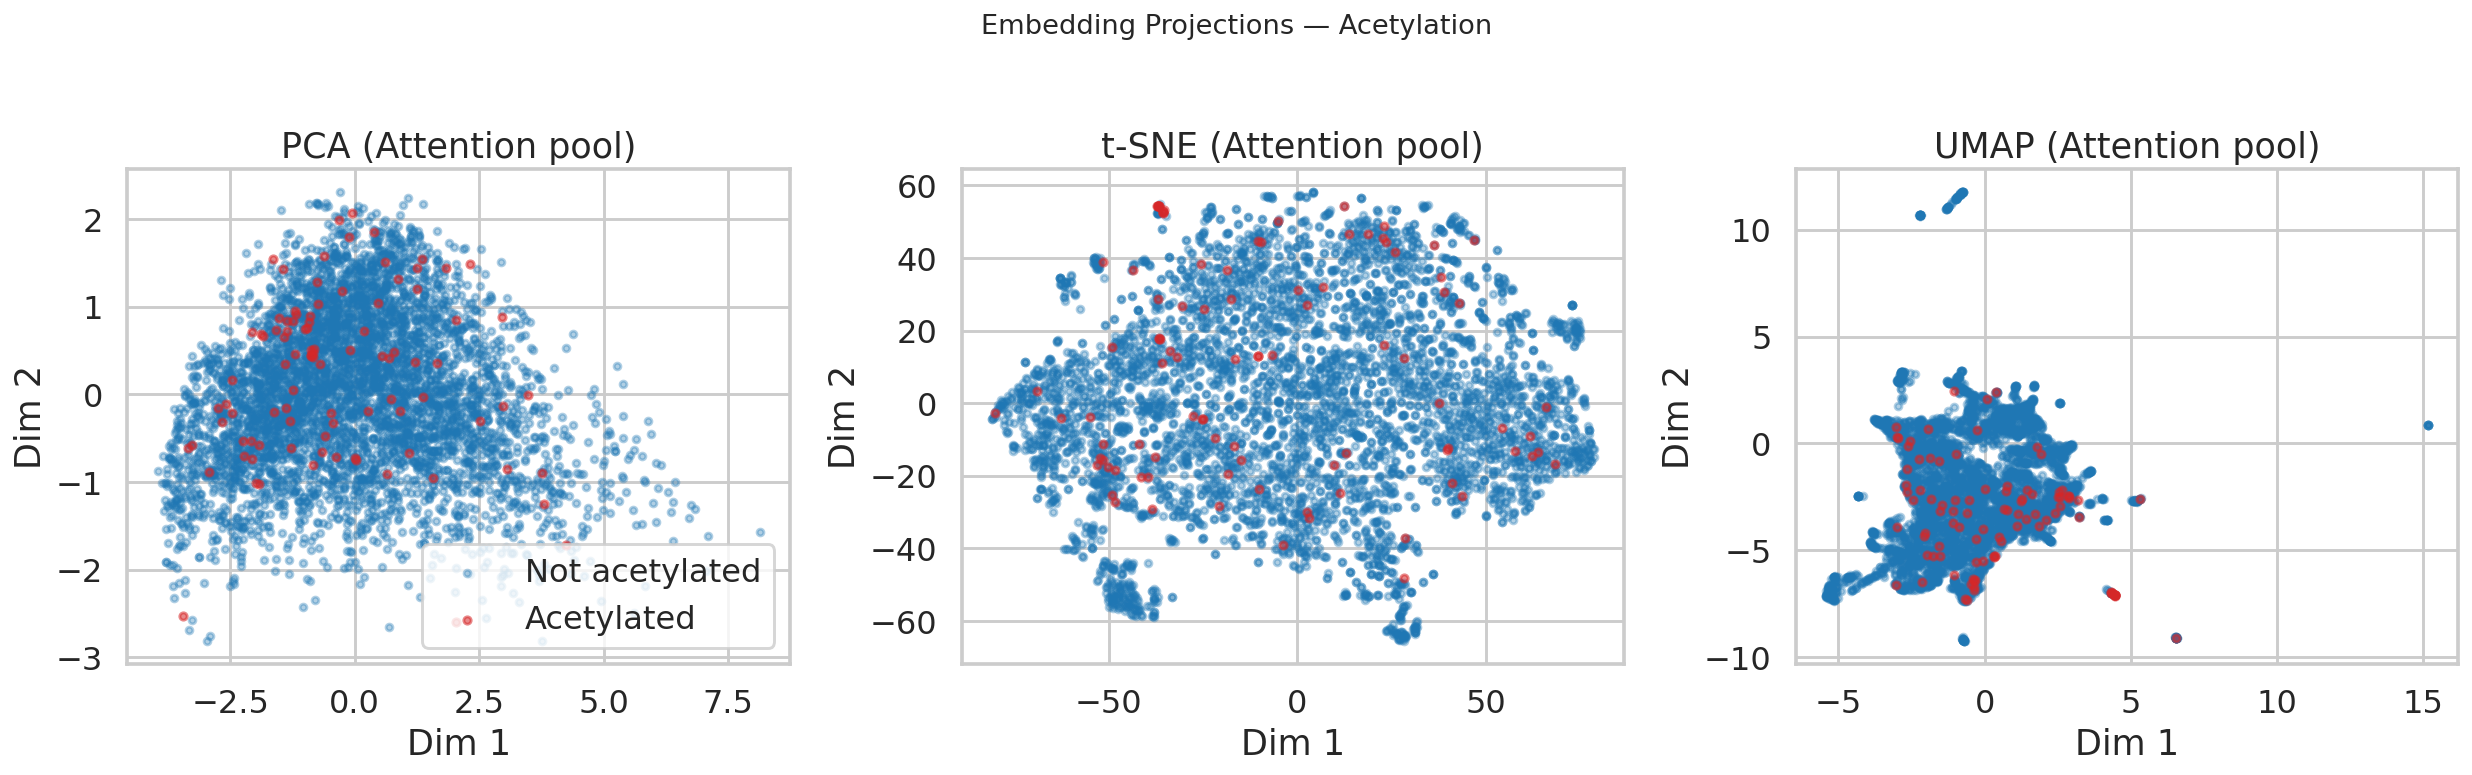

Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/embedding_projection_pca_tsne_umap.png


In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap as umap_lib

X_vis = np.vstack([X_pos_attn, X_neg_attn])
y_vis = np.array(
    ["Acetylated"]     * len(X_pos_attn) +
    ["Not acetylated"] * len(X_neg_attn)
)

max_vis = 5000
if len(X_vis) > max_vis:
    rng     = np.random.default_rng(SEED)
    idx_pos = np.where(y_vis == "Acetylated")[0]
    idx_neg = np.where(y_vis == "Not acetylated")[0]
    n_pos   = max(1, int(max_vis * len(idx_pos) / len(X_vis)))
    n_neg   = max_vis - n_pos
    sample_idx = np.concatenate([
        rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False),
        rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False),
    ])
    X_sub = X_vis[sample_idx]
    y_sub = y_vis[sample_idx]
else:
    X_sub, y_sub = X_vis, y_vis

n_pos_sub = (y_sub == "Acetylated").sum()
print(f"Visualising {len(X_sub):,} points ({n_pos_sub} pos, {len(X_sub)-n_pos_sub} neg)")

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_sub)

t0 = time.perf_counter()
tsne_2d = TSNE(n_components=2, init="pca", learning_rate="auto",
               perplexity=30, random_state=SEED).fit_transform(X_sub)
print(f"t-SNE complete in {time.perf_counter()-t0:.1f}s")

t0 = time.perf_counter()
umap_2d = umap_lib.UMAP(n_neighbors=15, min_dist=0.1,
                         metric="cosine", random_state=SEED).fit_transform(X_sub)
print(f"UMAP complete in {time.perf_counter()-t0:.1f}s")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, emb, title in [
    (axes[0], pca_2d,  "PCA"),
    (axes[1], tsne_2d, "t-SNE"),
    (axes[2], umap_2d, "UMAP"),
]:
    idx_neg = y_sub == "Not acetylated"
    idx_pos = y_sub == "Acetylated"
    ax.scatter(emb[idx_neg, 0], emb[idx_neg, 1], s=12, alpha=0.35,
               c="#1f77b4", label="Not acetylated")
    ax.scatter(emb[idx_pos, 0], emb[idx_pos, 1], s=14, alpha=0.55,
               c="#d62728", label="Acetylated")
    ax.set_title(f"{title} (Attention pool)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
axes[0].legend(loc="best")
plt.suptitle("Embedding Projections — Acetylation", fontsize=14, y=1.02)
plt.tight_layout()
emb_path = RESULTS_DIR / "embedding_projection_pca_tsne_umap.png"
plt.savefig(emb_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {emb_path}")


In [ ]:
best_row = results_df.iloc[0]
n_pos    = len(acetyl_df)
n_neg    = len(nacetyl_df)
pos_frac = n_pos / (n_pos + n_neg)

summary_lines = [
    "ANALYSIS SUMMARY — ESM2 Acetylation Prediction",
    "=" * 50,
    f"Best model by ROC-AUC: {best_row['model']} + {best_row['pooling']}",
    f"ROC-AUC   : {best_row['roc_auc']:.4f}",
    f"PR-AUC    : {best_row['pr_auc']:.4f}",
    f"F1 score  : {best_row['f1']:.4f}",
    f"Accuracy  : {(best_row['tp'] + best_row['tn']) / best_row['n_test']:.4f}",
    f"MCC       : {best_row['mcc']:.4f}",
    "",
    "Dataset:",
    f"  Acetylated proteins     : {n_pos:,}",
    f"  Non-acetylated proteins : {n_neg:,}",
    f"  Imbalance ratio         : ~1:{n_neg // n_pos}",
    "",
    "Interpretation:",
    "- ROC-AUC is the primary metric (class-agnostic ranking).",
    "- PR-AUC is secondary — critical for imbalanced binary tasks.",
    "- ESM2 uses 1280-dim pooled protein language model embeddings.",
    "- Imbalance handled via BCEWithLogitsLoss pos_weight + LR class_weight=balanced.",
    "- Labels from UniProt 'Post-translational modification' free-text field.",
]

analysis_path = RESULTS_DIR / "analysis_summary.txt"
analysis_path.write_text("\n".join(summary_lines))
print("\n".join(summary_lines))
print(f"\nSaved: {analysis_path}")


ANALYSIS SUMMARY — ESM2 Acetylation Prediction
Best model by ROC-AUC: mlp + attn
ROC-AUC   : 0.8146
PR-AUC    : 0.2273
F1 score  : 0.2192
Accuracy  : 0.9537
MCC       : 0.2127

Dataset:
  Acetylated proteins     : 354
  Non-acetylated proteins : 18,105
  Imbalance ratio         : ~1:51

Interpretation:
- ROC-AUC is the primary metric (class-agnostic ranking).
- PR-AUC is secondary — critical for imbalanced binary tasks.
- ESM2 uses 1280-dim pooled protein language model embeddings.
- Imbalance handled via BCEWithLogitsLoss pos_weight + LR class_weight=balanced.
- Labels from UniProt 'Post-translational modification' free-text field.

Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/analysis_summary.txt


In [12]:
import base64

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

# ---- Gather numbers ----
n_acetyl  = len(acetyl_df)
n_nacetyl = len(nacetyl_df)
n_total   = n_acetyl + n_nacetyl
pos_frac  = n_acetyl / n_total
emb_dim   = X_pos_attn.shape[1]
n_test    = int(results_df["n_test"].iloc[0])

best         = results_df.iloc[0]
best_model   = best["model"].replace("_", " ").title()
best_pooling = best["pooling"].upper()

# ---- Metrics table ----
def fmt_row(idx, r):
    m  = r["model"].replace("_", " ").title()
    p  = r["pooling"].upper()
    bg = ' style="background:#fff9e6"' if idx == 0 else ""
    return (
        f"<tr{bg}>"
        f"<td>{m}</td><td>{p}</td>"
        f"<td>{r['roc_auc']:.4f}</td>"
        f"<td><b>{r['pr_auc']:.4f}</b></td>"
        f"<td>{r['precision']:.4f}</td>"
        f"<td>{r['recall']:.4f}</td>"
        f"<td>{r['f1']:.4f}</td>"
        f"<td>{r['mcc']:.4f}</td>"
        f"<td>{r['tp']}</td><td>{r['fp']}</td>"
        f"<td>{r['tn']}</td><td>{r['fn']}</td>"
        "</tr>"
    )

table_rows = "\n".join(fmt_row(i, r) for i, (_, r) in enumerate(results_df.iterrows()))

# ---- Encode figures ----
fig_class = img_to_b64(RESULTS_DIR / "class_distribution.png")
fig_roc   = img_to_b64(RESULTS_DIR / "roc_curves.png")
fig_pr    = img_to_b64(RESULTS_DIR / "pr_curves.png")
fig_cm    = img_to_b64(RESULTS_DIR / "confusion_matrices.png")
fig_loss  = img_to_b64(RESULTS_DIR / "mlp_training_loss.png")
fig_emb   = img_to_b64(RESULTS_DIR / "embedding_projection_pca_tsne_umap.png")

# ---- Deltas ----
def _pr(model_name, pool_name):
    row = results_df[(results_df["model"] == model_name) &
                     (results_df["pooling"] == pool_name)]
    return row["pr_auc"].values[0] if len(row) else float("nan")

delta_mlp = _pr("mlp", "attn") - _pr("mlp", "max")
delta_lr  = _pr("logistic_regression", "attn") - _pr("logistic_regression", "max")

# ---- Build HTML ----
model_label = "ESM2"
notebook_name = "ESM2_acetylation_clean_pipeline.ipynb"

html = f"""<!DOCTYPE html>
<html lang=\"en\">
<head>
<meta charset=\"UTF-8\">
<title>ESM2 Acetylation Prediction &mdash; Interpretation Report</title>
<style>
  body  {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1100px; margin: 40px auto; padding: 0 30px; color: #222; line-height: 1.65; }}
  h1    {{ color: #1a3a5c; border-bottom: 3px solid #1a3a5c; padding-bottom: 8px; }}
  h2    {{ color: #2e6da4; margin-top: 42px; }}
  h3    {{ color: #444; margin-top: 24px; }}
  table {{ border-collapse: collapse; width: 100%; margin: 14px 0; font-size: 0.93em; }}
  th    {{ background: #1a3a5c; color: #fff; padding: 8px 10px; text-align: left; }}
  td    {{ padding: 7px 10px; border: 1px solid #ddd; }}
  tr:nth-child(even) td {{ background: #f4f8ff; }}
  .metric-box {{ display: inline-block; background: #f0f6ff; border: 1px solid #b3cde0;
                 border-radius: 6px; padding: 12px 22px; margin: 8px 8px 8px 0;
                 text-align: center; min-width: 130px; vertical-align: top; }}
  .metric-box .val {{ font-size: 1.75em; font-weight: bold; color: #1a3a5c; }}
  .metric-box .lbl {{ font-size: 0.8em; color: #666; margin-top: 4px; }}
  img   {{ max-width: 100%; border: 1px solid #ddd; border-radius: 4px; display: block; margin: 12px auto; }}
  .two-col {{ display: flex; gap: 20px; flex-wrap: wrap; align-items: flex-start; }}
  .two-col > div {{ flex: 1 1 45%; min-width: 300px; }}
  .caption {{ font-size: 0.85em; color: #555; text-align: center; margin-top: 4px; font-style: italic; }}
  .note  {{ background: #f9f9f9; border-left: 4px solid #2e6da4; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  hr     {{ border: none; border-top: 1px solid #ddd; margin: 32px 0; }}
  code   {{ background: #f4f4f4; padding: 1px 5px; border-radius: 3px; font-size: 0.9em; }}
</style>
</head>
<body>

<h1>ESM2 Acetylation Prediction &mdash; Interpretation Report</h1>
<p style=\"color:#555; font-size:0.9em\">
  Source: <code>{{notebook_name}}</code> &nbsp;|&nbsp;
  Embeddings: ESM2 protein language model (1280-dim) &nbsp;|&nbsp;
  Task: binary protein-level acetylation classification
</p>

<hr>

<h2>1. Dataset</h2>
<p>Proteins from the manually curated UniProt/Swiss-Prot proteome were split into
two mutually exclusive classes using the free-text <em>Post-translational modification</em> column:</p>
<ul>
  <li><b>Positive (acetylated)</b>: entry contains the string <code>acetyl</code> in the PTM field</li>
  <li><b>Negative (not acetylated)</b>: no acetylation mention in the PTM field</li>
</ul>
<div>
  <div class=\"metric-box\"><div class=\"val\">{n_acetyl:,}</div><div class=\"lbl\">Acetylated</div></div>
  <div class=\"metric-box\"><div class=\"val\">{n_nacetyl:,}</div><div class=\"lbl\">Not acetylated</div></div>
  <div class=\"metric-box\"><div class=\"val\">{n_total:,}</div><div class=\"lbl\">Total proteins</div></div>
  <div class=\"metric-box\"><div class=\"val\">{pos_frac:.1%}</div><div class=\"lbl\">Positive fraction</div></div>
  <div class=\"metric-box\"><div class=\"val\">{n_test:,}</div><div class=\"lbl\">Test set size (20%)</div></div>
  <div class=\"metric-box\"><div class=\"val\">{emb_dim}</div><div class=\"lbl\">Embedding dim</div></div>
</div>
<img src=\"data:image/png;base64,{fig_class}\" style=\"max-width:500px\">
<p class=\"caption\">Figure 1. Class distribution. Acetylated proteins represent {pos_frac:.1%} of the dataset.</p>
<div class=\"note\">
  <b>Class imbalance note:</b> With {pos_frac:.1%} positive examples,
  <b>PR-AUC (Average Precision)</b> is a key secondary metric.
  A random classifier achieves PR-AUC &asymp; {pos_frac:.3f}.
  Models are trained with imbalance corrections
  (<code>class_weight=\"balanced\"</code> for LR; <code>BCEWithLogitsLoss pos_weight</code> for MLP).
</div>
<hr>

<h2>2. Methods</h2>
<h3>2.1 Embeddings</h3>
<p>Precomputed <b>ESM2</b> protein language model embeddings (1280-dim) were
loaded from a pre-built NPZ cache. Two global sequence representations:</p>
<ul>
  <li><b>Max pooling</b> &mdash; element-wise maximum across residues</li>
  <li><b>Attention pooling</b> &mdash; learned weighted average across residues</li>
</ul>
<p>Features were z-score normalised (StandardScaler) using training statistics only.</p>
<h3>2.2 Classifiers</h3>
<table>
  <tr><th>Model</th><th>Architecture / Settings</th><th>Imbalance handling</th></tr>
  <tr><td>Logistic Regression</td><td>L2 penalty, max_iter=5000, n_jobs=-1</td>
      <td>class_weight=\"balanced\"</td></tr>
  <tr><td>MLP (PyTorch)</td>
      <td>Linear(1280&rarr;512) &rarr; ReLU &rarr; Dropout(0.3) &rarr;
          Linear(512&rarr;256) &rarr; ReLU &rarr; Dropout(0.3) &rarr; Linear(256&rarr;1),
          Adam lr=1e-3, 30 epochs, batch=64</td>
      <td>BCEWithLogitsLoss pos_weight=neg/pos</td></tr>
</table>
<hr>

<h2>3. Results</h2>
<h3>3.1 Performance Table</h3>
<table>
  <tr>
    <th>Model</th><th>Pooling</th>
    <th>ROC-AUC &#9733;</th><th>PR-AUC</th>
    <th>Precision</th><th>Recall</th><th>F1</th><th>MCC</th>
    <th>TP</th><th>FP</th><th>TN</th><th>FN</th>
  </tr>
  {table_rows}
</table>
<p class=\"caption\">Random PR-AUC baseline &asymp; {pos_frac:.3f}. Threshold=0.5 for CM.</p>
<h3>3.2 Best Model</h3>
<div>
  <div class=\"metric-box\"><div class=\"val\">{best['roc_auc']:.4f}</div><div class=\"lbl\">ROC-AUC &#9733;</div></div>
  <div class=\"metric-box\"><div class=\"val\">{best['pr_auc']:.4f}</div><div class=\"lbl\">PR-AUC</div></div>
  <div class=\"metric-box\"><div class=\"val\">{best['precision']:.4f}</div><div class=\"lbl\">Precision</div></div>
  <div class=\"metric-box\"><div class=\"val\">{best['recall']:.4f}</div><div class=\"lbl\">Recall</div></div>
  <div class=\"metric-box\"><div class=\"val\">{best['f1']:.4f}</div><div class=\"lbl\">F1</div></div>
  <div class=\"metric-box\"><div class=\"val\">{best['mcc']:.4f}</div><div class=\"lbl\">MCC</div></div>
</div>
<p><b>Best:</b> {best_model} + {best_pooling} pooling</p>
<hr>

<h2>4. Figures</h2>
<h3>Figure 2 &amp; 3: ROC and PR Curves</h3>
<div class=\"two-col\">
  <div><img src=\"data:image/png;base64,{fig_roc}\">
  <p class=\"caption\">Figure 2. ROC curves.</p></div>
  <div><img src=\"data:image/png;base64,{fig_pr}\">
  <p class=\"caption\">Figure 3. PR curves. Dashed = random baseline ({pos_frac:.3f}).</p></div>
</div>
<h3>Figure 4: Confusion Matrices (threshold=0.5)</h3>
<img src=\"data:image/png;base64,{fig_cm}\">
<p class=\"caption\">Figure 4.</p>
<h3>Figure 5: MLP Training Loss</h3>
<img src=\"data:image/png;base64,{fig_loss}\" style=\"max-width:640px\">
<p class=\"caption\">Figure 5. BCE loss per epoch.</p>
<h3>Figure 6: Embedding Space (PCA / t-SNE / UMAP)</h3>
<img src=\"data:image/png;base64,{fig_emb}\">
<p class=\"caption\">Figure 6. Acetylated (red) vs non-acetylated (blue).</p>
<hr>

<h2>5. Interpretation</h2>
<h3>5.1 Overall Performance</h3>
<p>
Best model ({best_model} + {best_pooling}) achieves ROC-AUC={best['roc_auc']:.4f},
PR-AUC={best['pr_auc']:.4f}, F1={best['f1']:.4f}, MCC={best['mcc']:.4f}.
PR-AUC of {best['pr_auc']:.4f} vs random baseline {pos_frac:.3f} represents
<b>{best['pr_auc']/pos_frac:.1f}&times; improvement over chance</b>.
</p>
<h3>5.2 Pooling Comparison</h3>
<p>Attention vs max-pool delta: MLP +{delta_mlp:+.3f}, LR +{delta_lr:+.3f} (PR-AUC).</p>
<h3>5.3 Acetylation as a Prediction Target</h3>
<ul>
  <li><b>Label source:</b> Free-text PTM field &mdash; may include N-terminal acetylation,
      lysine acetylation, and other acetyl modifications in one label.</li>
  <li><b>Imbalance:</b> Only {pos_frac:.1%} of proteins carry an acetylation annotation.
      This makes PR-AUC critical; ROC-AUC can be misleadingly high.</li>
  <li><b>Bottleneck:</b> Global pooling discards residue-position information;
      acetylation signals (e.g., N-terminal Ala/Met motifs) are inherently local.</li>
</ul>
<hr>

<h2>6. Recommendations</h2>
<ol>
  <li>Stratify by acetylation type (N-terminal vs lysine).</li>
  <li>Train residue-level classifiers on per-token embeddings for site prediction.</li>
  <li>Replace single 80/20 split with 5-fold cross-validation.</li>
  <li>Benchmark against other PLMs (Ankh / ESM2 / ProtT5).</li>
</ol>
<hr>

<h2>7. Output Files</h2>
<table>
  <tr><th>File</th><th>Description</th></tr>
  <tr><td><code>summary_metrics.csv</code></td><td>All model metrics</td></tr>
  <tr><td><code>summary_metrics.md</code></td><td>Markdown table</td></tr>
  <tr><td><code>analysis_summary.txt</code></td><td>Best-model summary</td></tr>
  <tr><td><code>class_distribution.png</code></td><td>Class balance chart</td></tr>
  <tr><td><code>roc_curves.png</code></td><td>ROC curves</td></tr>
  <tr><td><code>pr_curves.png</code></td><td>PR curves</td></tr>
  <tr><td><code>confusion_matrices.png</code></td><td>4 confusion matrices</td></tr>
  <tr><td><code>mlp_training_loss.png</code></td><td>MLP BCE loss</td></tr>
  <tr><td><code>embedding_projection_pca_tsne_umap.png</code></td><td>PCA/t-SNE/UMAP</td></tr>
  <tr><td><code>interpretation_report.html</code></td><td>This report</td></tr>
</table>
<hr>
<p style=\"color:#888; font-size:0.82em\">
  <b>To convert to .docx:</b> Open in Microsoft Word &rarr; File &rarr; Save As &rarr; .docx
</p>
</body>
</html>"""

report_path = RESULTS_DIR / "interpretation_report.html"
report_path.write_text(html, encoding="utf-8")
print(f"Saved: {report_path}")
print("\nTo convert to .docx:")
print("  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx")


Saved: /home/saishyam/Protein_dynamics/acetylation/Claude_Agent_Acetylation/results_acetylation_ESM2/interpretation_report.html

To convert to .docx:
  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx
